# 04 · Risco de Estouro de OLA (Regressão Logística)

**Projeto:** Cronos · Challenge FIAP 2026 com Locaweb
**Autor(es):** Ana Beatriz Costa de Oliveira · Hygor Abrantes · Igor Vignola
**Data de criação:** 04/08/2026
**Última atualização:** 04/08/2026

## Objetivo

Estimar, no momento da abertura de cada incidente, a probabilidade de ele estourar o OLA, e
ordenar a fila de atendimento por esse risco. O modelo escolhido é a regressão logística,
comparada contra três regras operacionais simples e contra o XGBoost.

Complementa o `03_previsao_volume.ipynb`: a previsão de volume dimensiona a carga do dia, e este
modelo aponta quais incidentes dessa carga exigem atenção. A separação de papéis vem de um achado do
notebook anterior, no qual o volume diário explicou apenas 2,5% da variação no número de quebras.

## Dependências

- Python 3.11+
- pandas, numpy, matplotlib
- scikit-learn, xgboost, holidays

## Entradas

- `data/interim/incidentes_kpi.parquet` (gerado pelo `02_base_kpi.ipynb`)

## Saídas

- Gráficos exportados para `notebooks/figures/04_risco_ola/`
- Resultados documentados em `docs/sprint-3-mvp.md`

## Sumário

| Seção | Conteúdo |
|---|---|
| 3 | a variável-alvo e onde as quebras se concentram |
| 4.1 a 4.3 | desenho da validação, características e treino |
| 4.4 e 4.5 | baselines operacionais e a leitura por triagem |
| 4.6 e 4.7 | métricas de classificação e comparação com o XGBoost |
| 4.8 | calibração do risco informado |
| 4.9 | explicabilidade por incidente, sem SHAP |
| 4.10 | verificações de robustez |
| 5 | conclusões |

In [1]:
# Stdlib
import warnings
from pathlib import Path

# Third-party
import holidays
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Raiz do repositório (permite executar o notebook de qualquer diretório)
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'interim').exists())

## 1. Setup

Paleta e estilo dos gráficos (padrão visual do projeto), caminhos de entrada e saída, e funções
auxiliares usadas ao longo do notebook.

In [2]:
COR = {'preto': '#000000', 'cinza_esc': '#444444', 'cinza': '#888888',
       'accent': '#2563EB', 'danger': '#DC2626', 'ambar': '#D97706', 'verde': '#15A05B'}
mpl.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#E5E5E5', 'grid.linewidth': 0.5,
    'xtick.color': '#888888', 'ytick.color': '#888888',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'], 'font.size': 10,
    'legend.frameon': False,
})
plt.rcParams['axes.grid.axis'] = 'y'

PARQUET = RAIZ / 'data' / 'interim' / 'incidentes_kpi.parquet'
assert PARQUET.exists(), 'parquet não encontrado. Execute o 02_base_kpi.ipynb antes.'

FIG_DIR = RAIZ / 'notebooks' / 'figures' / '04_risco_ola'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEMENTE = 42

def fmt(x, casas=2):
    """Formata número no padrão PT-BR (vírgula decimal)."""
    return f'{x:.{casas}f}'.replace('.', ',')

def fmt_int(x):
    """Formata inteiro no padrão PT-BR (ponto de milhar)."""
    return f'{int(x):,}'.replace(',', '.')

def salvar_fig(fig, nome):
    fig.savefig(FIG_DIR / f'{nome}.png', dpi=150, bbox_inches='tight')

## 2. Carga dos dados

Base compartilhada de incidentes elegíveis ao KPI, preparada pelo `02_base_kpi.ipynb`. A variável-alvo
é derivada do campo oficial `KPI Violado?`.

In [3]:
df_kpi = pd.read_parquet(PARQUET)
df_kpi['violou'] = (df_kpi['KPI Violado?'] == 'SIM').astype(int)

# feriados nacionais: o dataset não traz essa informação
feriados_br = holidays.Brazil(years=sorted(df_kpi['ano'].unique().tolist()))
df_kpi['is_feriado'] = df_kpi['dia'].dt.date.map(lambda d: int(d in feriados_br))

assert len(df_kpi) == 25_600, f'esperadas 25.600 linhas, encontradas {len(df_kpi)}'
print(f'Base carregada: {fmt_int(len(df_kpi))} incidentes elegíveis ao KPI')
print(f'Quebras de OLA: {fmt_int(df_kpi["violou"].sum())}')

Base carregada: 25.600 incidentes elegíveis ao KPI
Quebras de OLA: 248


## 3. Visão geral

Conferência da base antes da modelagem. A validação completa está no `02_base_kpi.ipynb`.

In [4]:
display(df_kpi.head())
print(f"Período: {df_kpi['dia'].min():%d/%m/%Y} a {df_kpi['dia'].max():%d/%m/%Y}")
print('\nElegíveis por ano:')
print(df_kpi['ano'].value_counts().sort_index().to_string())

,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?,dia,dia_semana,hora,ano,mes,violou,is_feriado
0,INC8654075,2 - Alta,lrel,cat85,sub81,Team09,IC00055,2025-12-31 18:06:15,2025-12-31 19:36:58,2025-12-31 20:13:42,5443,Falha de Aplicação,IC00731 locaweb em instalação,Contorno,Manual,None,Encerrado,SIM,NAO,2025-12-31,2,18,2025,12,0,0
1,INC8653993,2 - Alta,lhvp,cat73,sub369,Team14,IC00067,2025-12-31 14:45:31,2025-12-31 15:19:43,2025-12-31 15:52:08,2052,Falha de Sistema Operacional,[IC00067] Servidor inacessível,Contorno,Manual,None,Encerrado,SIM,NAO,2025-12-31,2,14,2025,12,0,0
2,INC8653923,2 - Alta,lhco,cat71,sub7,Team14,IC00082,2025-12-31 11:43:57,2025-12-31 12:06:59,2025-12-31 12:08:36,1382,Falha de Sistema Operacional,Problem: Check: Varnish Type: tcp on Port: 80 ...,Contorno,Monitoramento,None,Encerrado,SIM,NAO,2025-12-31,2,11,2025,12,0,0
3,INC8653899,2 - Alta,lssl,cat102,sub362,Team14,IC00083,2025-12-31 11:13:53,2025-12-31 11:38:35,2025-12-31 11:55:53,1482,Falha de Sistema Operacional,Problem: Pool: /Common/xpl_lw-ssl_panel_https ...,Contorno,Monitoramento,None,Encerrado,SIM,NAO,2025-12-31,2,11,2025,12,0,0
4,INC8653798,2 - Alta,lrev,cat97,sub39,Team14,IC00095,2025-12-31 07:15:16,2025-12-31 07:36:27,2025-12-31 07:52:03,1271,Falha de Banco de Dados,Problem: Check MS SQL Response Test,Contorno,Monitoramento,None,Encerrado,SIM,NAO,2025-12-31,2,7,2025,12,0,0


Período: 02/01/2023 a 31/12/2025

Elegíveis por ano:
ano
2023       87
2024      357
2025    25156


### 3.1 A variável-alvo

O alvo é binário: o incidente estourou o OLA ou não. A proporção de casos positivos determina o
desenho da avaliação, porque com evento raro a maioria das métricas usuais perde utilidade.

In [5]:
TAXA_GERAL = df_kpi['violou'].mean()

print(f'incidentes elegíveis .... {fmt_int(len(df_kpi))}')
print(f'quebras de OLA .......... {fmt_int(df_kpi["violou"].sum())}')
print(f'prevalência ............. {fmt(TAXA_GERAL * 100)}%')
print(f'proporção ............... 1 quebra a cada {int(round(1 / TAXA_GERAL))} incidentes')
print()
print('por ano:')
por_ano = df_kpi.groupby('ano').agg(incidentes=('violou', 'size'), quebras=('violou', 'sum'))
por_ano['taxa %'] = (por_ano['quebras'] / por_ano['incidentes'] * 100).round(2)
print(por_ano.to_string())

incidentes elegíveis .... 25.600
quebras de OLA .......... 248
prevalência ............. 0,97%
proporção ............... 1 quebra a cada 103 incidentes

por ano:
      incidentes  quebras  taxa %
ano                              
2023          87        4    4.60
2024         357        6    1.68
2025       25156      238    0.95


**Achado:** a prevalência de 0,97% caracteriza um problema de classificação fortemente
desbalanceado, com aproximadamente uma quebra a cada cem incidentes. Duas consequências para a
avaliação, tratadas nas seções 4.6 e 4.8:

1. a acurácia deixa de ser informativa, porque prever "não vai estourar" para tudo já acerta 99%;
2. o volume de casos positivos é pequeno em termos absolutos, o que impõe cautela na leitura de
   qualquer métrica calculada sobre subconjuntos.

### 3.2 Onde as quebras se concentram

Antes de treinar, uma verificação de que existe sinal a ser capturado. Se as quebras estivessem
distribuídas de forma homogênea entre times, produtos e prioridades, nenhum modelo baseado nessas
características conseguiria ordená-las.

In [6]:
def concentracao(coluna, minimo=200, topo=6):
    """Taxa de quebra por valor da coluna, restrita a valores com volume relevante."""
    g = df_kpi.groupby(df_kpi[coluna].astype(str)).agg(
        incidentes=('violou', 'size'), quebras=('violou', 'sum'))
    g = g[g['incidentes'] >= minimo]
    g['taxa %'] = (g['quebras'] / g['incidentes'] * 100).round(2)
    g['vezes a média'] = (g['quebras'] / g['incidentes'] / TAXA_GERAL).round(2)
    return g.sort_values('taxa %', ascending=False).head(topo)

for col in ['Prioridade', 'Grupo designado', 'Produto']:
    print(f'--- {col} (valores com pelo menos 200 incidentes) ---')
    print(concentracao(col).to_string())
    print()

--- Prioridade (valores com pelo menos 200 incidentes) ---


            incidentes  quebras  taxa %  vezes a média
Prioridade                                            
3 - Média        20441      206    1.01           1.04
2 - Alta          5159       42    0.81           0.84

--- Grupo designado (valores com pelo menos 200 incidentes) ---
                 incidentes  quebras  taxa %  vezes a média
Grupo designado                                            
Team03                  415       12    2.89           2.98
Team09                 2058       56    2.72           2.81
Team12                  395        8    2.03           2.09
Team02                  251        4    1.59           1.65
Team11                 8702      114    1.31           1.35
Team17                  484        4    0.83           0.85

--- Produto (valores com pelo menos 200 incidentes) ---


         incidentes  quebras  taxa %  vezes a média
Produto                                            
lvps            423       10    2.36           2.44
lssl            455        9    1.98           2.04
lsin           3259       63    1.93           2.00
lgoa            401        7    1.75           1.80
lrdo            490        8    1.63           1.69
lsaa            572        8    1.40           1.44



**Achado:** existe concentração aproveitável. Entre os grupos designados com pelo menos 200
incidentes, a taxa de quebra vai de 0,83% a 2,89%, o que corresponde a uma variação de até três vezes
a média da base. O mesmo vale para o produto, de 1,40% a 2,36%.

A prioridade, ao contrário, praticamente não separa: o P2 fica em 0,84 vez a média e o P3 em 1,04
vez. O P2, de prioridade mais alta, estoura menos. Esse comportamento é investigado na seção
4.10.3.

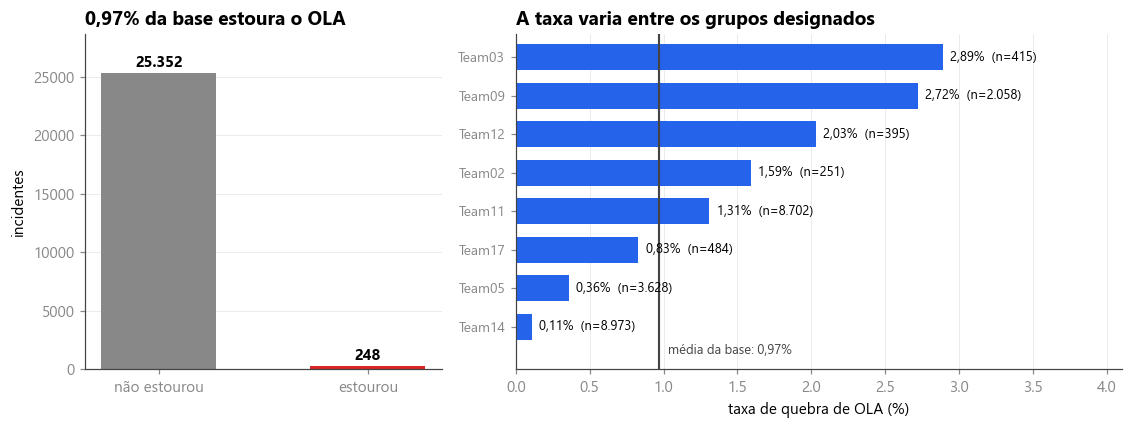

In [7]:
# figura 01: o desbalanceamento e a concentração por grupo designado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.4, 4.0), gridspec_kw={'width_ratios': [1, 1.7]})

ax1.bar(['não estourou', 'estourou'],
        [len(df_kpi) - df_kpi['violou'].sum(), df_kpi['violou'].sum()],
        color=[COR['cinza'], COR['danger']], width=0.55)
for i, v in enumerate([len(df_kpi) - df_kpi['violou'].sum(), df_kpi['violou'].sum()]):
    ax1.text(i, v + 500, fmt_int(v), ha='center', fontweight='bold', fontsize=10)
ax1.set_ylim(0, len(df_kpi) * 1.12)
ax1.set_ylabel('incidentes')
ax1.set_title(f'{fmt(TAXA_GERAL*100)}% da base estoura o OLA', loc='left')

g = concentracao('Grupo designado', topo=8).sort_values('taxa %')
ax2.barh(range(len(g)), g['taxa %'], color=COR['accent'], height=0.68)
ax2.axvline(TAXA_GERAL * 100, color=COR['cinza_esc'], lw=1.4)
ax2.text(TAXA_GERAL * 100 + 0.06, -0.62, f'média da base: {fmt(TAXA_GERAL*100)}%',
         fontsize=8.5, color=COR['cinza_esc'], va='center')
for i, (t, n) in enumerate(zip(g['taxa %'], g['incidentes'])):
    ax2.text(t + 0.05, i, f'{fmt(t)}%  (n={fmt_int(n)})', va='center', fontsize=8.5)
ax2.set_yticks(range(len(g))); ax2.set_yticklabels(g.index, fontsize=9)
ax2.set_xlim(0, g['taxa %'].max() * 1.42); ax2.set_ylim(-1.1, len(g) - 0.4)
ax2.set_xlabel('taxa de quebra de OLA (%)')
ax2.set_title('A taxa varia entre os grupos designados', loc='left')
ax2.grid(axis='y', visible=False); ax2.grid(axis='x', visible=True)

plt.tight_layout(); salvar_fig(fig, '01_alvo_e_concentracao'); plt.show()

## 4. Modelagem

### 4.1 Desenho da validação: corte temporal

O modelo será usado para decidir a ordem de atendimento de incidentes que ainda não aconteceram. A
validação precisa reproduzir essa condição, o que exige separar treino e teste **por data** e não de
forma aleatória.

Uma separação aleatória permitiria ao modelo aprender com incidentes de dezembro para prever
incidentes de outubro. O erro medido dessa forma é otimista e não corresponde ao uso real.

O corte adotado é 01/10/2025: treino até setembro, teste de outubro a dezembro.

In [8]:
CORTE = pd.Timestamp('2025-10-01')
df_treino = df_kpi[df_kpi['dia'] < CORTE].copy()
df_teste = df_kpi[df_kpi['dia'] >= CORTE].copy()

y_treino = df_treino['violou'].values
y_teste = df_teste['violou'].values
N_TESTE = len(y_teste)
Q_TESTE = int(y_teste.sum())
TAXA_TREINO = y_treino.mean()

assert df_treino['dia'].max() < df_teste['dia'].min(), 'sobreposição temporal entre treino e teste'

print(f'treino: {fmt_int(len(df_treino))} incidentes até {df_treino["dia"].max():%d/%m/%Y} '
      f'({fmt_int(y_treino.sum())} quebras)')
print(f'teste:  {fmt_int(N_TESTE)} incidentes de {df_teste["dia"].min():%d/%m/%Y} a '
      f'{df_teste["dia"].max():%d/%m/%Y} ({Q_TESTE} quebras)')
print(f'prevalência no teste: {fmt(Q_TESTE / N_TESTE * 100)}%')
print(f'desbalanceamento no treino: {int((y_treino==0).sum() / y_treino.sum())} para 1')

treino: 20.417 incidentes até 30/09/2025 (198 quebras)
teste:  5.183 incidentes de 01/10/2025 a 31/12/2025 (50 quebras)
prevalência no teste: 0,96%
desbalanceamento no treino: 102 para 1


**Achado:** o conjunto de teste reúne 50 quebras. Esse número limita a precisão de qualquer
métrica calculada sobre ele e é declarado como limitação em todas as leituras deste notebook.
Diferenças pequenas entre modelos não devem ser interpretadas como superioridade.

### 4.2 Características disponíveis no instante da abertura

A regra que define o conjunto de características é a informação disponível **quando o incidente é
aberto**. Campos preenchidos durante ou após o atendimento não podem entrar, porque não estariam
disponíveis no momento em que a previsão precisa ser feita.

| Campo | Situação | Motivo |
|---|---|---|
| `Prioridade`, `Produto`, `Categoria`, `Subcategoria` | usado | classificação feita na abertura |
| `Grupo designado`, `Item de configuração`, `Aberto por` | usado | definidos na abertura |
| `hora`, `dia_semana`, `is_feriado` | usado | derivados do instante de abertura |
| `Duração` | **excluído** | só existe depois do fechamento |
| `Resolvido`, `Encerrado`, `Status` | **excluído** | posteriores à abertura |
| `Código de fechamento`, `Solução` | **excluído** | preenchidos no fechamento |
| `KPI Violado?` | **excluído** | é o próprio alvo |

O campo `Duração` merece destaque: ele determina mecanicamente o estouro do OLA e produziria um
modelo de desempenho aparentemente perfeito e utilidade nula.

In [9]:
CATEGORICAS = ['Prioridade', 'Grupo designado', 'Aberto por', 'Produto',
               'Categoria', 'Subcategoria', 'Item de configuração']
NUMERICAS = ['hora', 'dia_semana', 'is_feriado']
CARACTERISTICAS = CATEGORICAS + NUMERICAS

# nenhum campo posterior à abertura pode estar na lista
POSTERIORES = ['Duração', 'Resolvido', 'Encerrado', 'Status', 'Código de fechamento',
               'Solução', 'KPI Violado?', 'violou']
assert not set(CARACTERISTICAS) & set(POSTERIORES), 'característica posterior à abertura na lista'

print(f'{len(CARACTERISTICAS)} características:')
for c in CATEGORICAS:
    print(f'  {c:24s} categórica  {df_kpi[c].nunique():5d} valores distintos')
for c in NUMERICAS:
    print(f'  {c:24s} numérica    {df_kpi[c].nunique():5d} valores distintos')

10 características:
  Prioridade               categórica      2 valores distintos
  Grupo designado          categórica     16 valores distintos
  Aberto por               categórica      2 valores distintos
  Produto                  categórica     45 valores distintos
  Categoria                categórica    119 valores distintos
  Subcategoria             categórica    383 valores distintos
  Item de configuração     categórica   4665 valores distintos
  hora                     numérica       24 valores distintos
  dia_semana               numérica        7 valores distintos
  is_feriado               numérica        2 valores distintos


### 4.3 Treino da regressão logística

As características categóricas são codificadas em colunas binárias, com os valores de frequência
inferior a cem agrupados em uma categoria residual. Sem esse agrupamento, o item de configuração
sozinho produziria mais de quatro mil colunas, quase todas com pouquíssimas observações.

As numéricas são padronizadas. Valores ausentes recebem imputação: categoria explícita no caso das
categóricas, mediana no caso das numéricas.

O regularizador padrão do scikit-learn (L2) é mantido, o que controla o crescimento dos coeficientes
em um espaço de mais de cem colunas com poucos casos positivos.

In [10]:
def novo_preprocessador():
    """Codificação das categóricas e padronização das numéricas."""
    return ColumnTransformer([
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='constant', fill_value='(vazio)')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=100)),
        ]), CATEGORICAS),
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc', StandardScaler()),
        ]), NUMERICAS),
    ])

def matriz_x(dados):
    """Recorta as características e força as categóricas a texto."""
    X = dados[CARACTERISTICAS].copy()
    X[CATEGORICAS] = X[CATEGORICAS].astype(str)
    return X

X_treino, X_teste = matriz_x(df_treino), matriz_x(df_teste)

modelo = Pipeline([('pre', novo_preprocessador()),
                   ('clf', LogisticRegression(max_iter=5000, random_state=SEMENTE))])
modelo.fit(X_treino, y_treino)

risco_teste = modelo.predict_proba(X_teste)[:, 1]
n_colunas = modelo.named_steps['pre'].transform(X_treino).shape[1]

print(f'{len(CARACTERISTICAS)} características -> {n_colunas} colunas após codificação')
print(f'convergiu em {modelo.named_steps["clf"].n_iter_[0]} iterações '
      f'(limite de {modelo.named_steps["clf"].max_iter})')
print()
print(f'risco estimado no teste: mínimo {fmt(risco_teste.min()*100, 3)}%, '
      f'mediana {fmt(np.median(risco_teste)*100)}%, máximo {fmt(risco_teste.max()*100, 1)}%')

10 características -> 136 colunas após codificação
convergiu em 25 iterações (limite de 5000)

risco estimado no teste: mínimo 0,007%, mediana 0,35%, máximo 56,1%


**Achado:** o modelo converge dentro do limite de iterações, o que descarta problema de ajuste
numérico. O risco estimado cobre uma faixa ampla, de frações de por cento até mais de cinquenta por
cento, o que é condição necessária para que a ordenação da fila seja informativa.

### 4.4 Baselines operacionais

Um modelo só se justifica se superar o que a operação faria sem ele. Comparar contra uma fila
aleatória é insuficiente, porque nenhuma operação atende incidentes em ordem aleatória.

Três regras, todas construídas **apenas com o período de treino**, de modo que nenhuma tenha acesso
ao desfecho dos incidentes de teste:

1. **prioridade**: P2 antes de P3, o comportamento padrão de qualquer ferramenta de ITSM;
2. **ativo crônico**: itens de configuração ordenados pelo número de quebras já registradas;
3. **time**: grupos designados ordenados pela taxa de quebra histórica.

Empates são resolvidos por sorteio com semente fixa, para que nenhuma regra seja favorecida pela
ordem original das linhas.

In [11]:
def ordena(score):
    """Fila do período de teste a partir de uma pontuação, com desempate aleatório fixo."""
    fila = df_teste[['Número', 'violou']].copy()
    fila['score'] = np.asarray(score, dtype=float)
    fila['desempate'] = np.random.default_rng(SEMENTE).random(len(fila))
    return (fila.sort_values(['score', 'desempate'], ascending=[False, True])
                .reset_index(drop=True))

score_prioridade = (df_teste['Prioridade'].astype(str) == '2 - Alta').astype(int).values

quebras_passadas = df_treino[df_treino['violou'] == 1]['Item de configuração'].value_counts()
score_ativo = df_teste['Item de configuração'].map(quebras_passadas).fillna(0).values

taxa_por_time = df_treino.groupby('Grupo designado')['violou'].mean()
score_time = df_teste['Grupo designado'].map(taxa_por_time).fillna(0).values

FILAS = {
    'modelo de risco': ordena(risco_teste),
    'baseline: por time': ordena(score_time),
    'baseline: ativo crônico': ordena(score_ativo),
    'baseline: por prioridade': ordena(score_prioridade),
}

print(f'itens de configuração com quebra no treino: {len(quebras_passadas)}')
print(f'os 5 mais crônicos: {quebras_passadas.head().to_dict()}')
print()
print('taxa de quebra histórica por time (as 5 maiores, em %):')
print((taxa_por_time.sort_values(ascending=False).head() * 100).round(2).to_string())

itens de configuração com quebra no treino: 109
os 5 mais crônicos: {'IC00349': 22, 'IC00840': 21, 'IC01285': 10, 'IC00251': 9, 'IC01012': 6}

taxa de quebra histórica por time (as 5 maiores, em %):
Grupo designado
Team06    10.81
Team07     7.14
Team08     6.82
Team01     3.33
Team03     3.10


### 4.5 A leitura por triagem

A pergunta que interessa à operação: percorrendo a fila de cima para baixo, quantas das 50 quebras
do período aparecem nos primeiros incidentes.

Esta é a leitura principal do notebook. As métricas convencionais vêm depois, na seção 4.6.

In [12]:
def achou(fila, quantos):
    return int(fila['violou'].head(quantos).sum())

MARCOS = [50, 100, 250, 518, 1000]

triagem = pd.DataFrame({'incidentes percorridos': MARCOS})
for nome, fila in FILAS.items():
    triagem[nome] = [achou(fila, k) for k in MARCOS]
triagem['sem ordenação'] = [round(Q_TESTE * k / N_TESTE, 1) for k in MARCOS]

melhor_base = triagem[[c for c in triagem.columns if c.startswith('baseline')]].max(axis=1)
triagem['ganho sobre o melhor baseline'] = (
    ((triagem['modelo de risco'] - melhor_base) / melhor_base * 100)
    .round(0).astype(int).astype(str) + '%')

print(f'quebras no período de teste: {Q_TESTE}')
print()
print(triagem.to_string(index=False))

quebras no período de teste: 50

 incidentes percorridos  modelo de risco  baseline: por time  baseline: ativo crônico  baseline: por prioridade  sem ordenação ganho sobre o melhor baseline
                     50               15                   6                        0                         1            0.5                          150%
                    100               17                   8                        1                         2            1.0                          112%
                    250               22                  14                        2                         4            2.4                           57%
                    518               29                  19                       16                         5            5.0                           53%
                   1000               36                  28                       27                         8            9.6                           29%


**Achado:** nos 50 primeiros incidentes da fila o modelo encontra 15 quebras, contra 6 da melhor
regra simples e 1 da ordenação por prioridade. O ganho sobre a melhor alternativa varia de 29% a
150% conforme o tamanho da fila, e é maior justamente no topo, que é a parte efetivamente usada.

A comparação com "sem ordenação" mostra a diferença de escala: percorrer 50 incidentes ao acaso
encontraria 0,5 quebra.

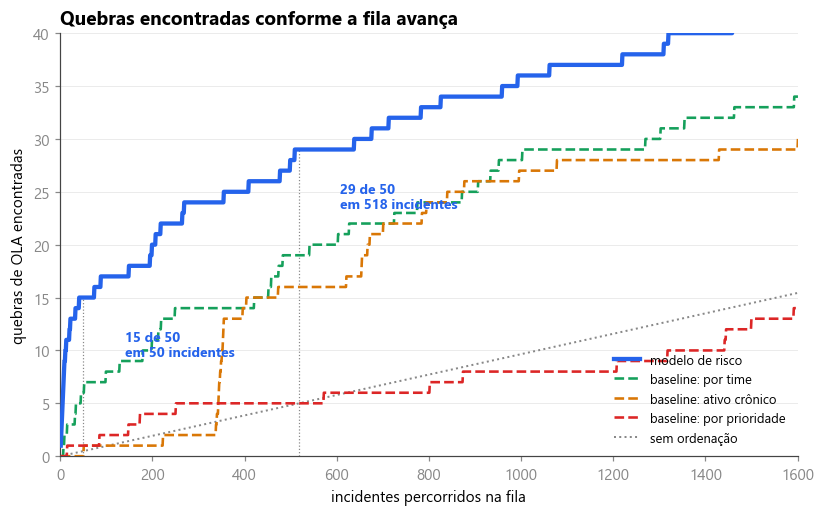

In [13]:
# figura 02: quebras encontradas conforme a fila avança
fig, ax = plt.subplots(figsize=(7.6, 4.8))
x = np.arange(1, N_TESTE + 1)

estilo = {'modelo de risco': (COR['accent'], 2.8, '-'),
          'baseline: por time': (COR['verde'], 1.7, '--'),
          'baseline: ativo crônico': (COR['ambar'], 1.7, '--'),
          'baseline: por prioridade': (COR['danger'], 1.7, '--')}
for nome, fila in FILAS.items():
    cor, lw, ls = estilo[nome]
    ax.plot(x, fila['violou'].cumsum(), color=cor, lw=lw, ls=ls, label=nome,
            zorder=5 if nome == 'modelo de risco' else 3)
ax.plot([0, N_TESTE], [0, Q_TESTE], color=COR['cinza'], lw=1.3, ls=':', label='sem ordenação')

acumulado = FILAS['modelo de risco']['violou'].cumsum().values
for k in (50, 518):
    ax.plot([k, k], [0, acumulado[k - 1]], color=COR['cinza'], lw=0.8, ls=':')
    ax.annotate(f'{acumulado[k-1]} de {Q_TESTE}\nem {k} incidentes',
                xy=(k, acumulado[k - 1]), xytext=(k + 90, acumulado[k - 1] - 5.5),
                color=COR['accent'], fontweight='bold', fontsize=9)

ax.set_xlim(0, 1600); ax.set_ylim(0, 40)
ax.set_xlabel('incidentes percorridos na fila')
ax.set_ylabel('quebras de OLA encontradas')
ax.set_title('Quebras encontradas conforme a fila avança', loc='left')
ax.legend(loc='lower right', fontsize=8.5)
plt.tight_layout(); salvar_fig(fig, '02_fila_vs_baselines'); plt.show()

### 4.6 Métricas de classificação

A leitura por triagem responde à pergunta da operação. Esta seção traduz o mesmo resultado para as
métricas convencionais de classificação.

#### 4.6.1 Por que a acurácia não é reportada

Acurácia é a proporção de acertos sobre o total. Com prevalência inferior a 1%, responder "não vai
estourar" para todos os incidentes já produz acurácia alta.

In [14]:
ORDEM = np.argsort(-risco_teste)

def decisao_topo(k):
    """Vetor de decisão que sinaliza apenas os k incidentes de maior risco."""
    d = np.zeros(N_TESTE, dtype=int); d[ORDEM[:k]] = 1
    return d

acuracia = lambda pred: (pred == y_teste).mean() * 100

print(f'nunca sinalizar nada ......... acurácia {fmt(acuracia(np.zeros(N_TESTE, dtype=int)))}%')
print(f'modelo, sinalizando 50 ....... acurácia {fmt(acuracia(decisao_topo(50)))}%')
print(f'modelo, sinalizando 518 ...... acurácia {fmt(acuracia(decisao_topo(518)))}%')

nunca sinalizar nada ......... acurácia 99,04%
modelo, sinalizando 50 ....... acurácia 98,65%
modelo, sinalizando 518 ...... acurácia 90,16%


**Achado:** o classificador que nunca sinaliza nada obtém acurácia superior à do modelo em
qualquer corte útil. A métrica premia a inação e por isso não integra a avaliação deste projeto. A
avaliação usa matriz de confusão por corte, precisão, cobertura, PR-AUC e a curva de ganho.

#### 4.6.2 Matriz de confusão por corte

Quatro resultados possíveis da combinação entre o que o modelo sinalizou e o que ocorreu. Os dois
tipos de erro têm custos distintos na operação: o alarme falso consome tempo do analista, enquanto o
caso não sinalizado que estoura conta no KPI.

In [15]:
def avalia_corte(pred, rotulo):
    tn, fp, fn, tp = confusion_matrix(y_teste, pred).ravel()
    return {'corte': rotulo, 'sinalizados': tp + fp, 'acertos': tp, 'alarmes falsos': fp,
            'quebras não vistas': fn, 'precisão %': round(tp / (tp + fp) * 100, 1) if tp + fp else np.nan,
            'cobertura %': round(tp / (tp + fn) * 100, 1)}

resultados = [avalia_corte((risco_teste >= 0.5).astype(int), 'risco >= 50% (regra padrão)')]
resultados += [avalia_corte(decisao_topo(k), f'os {k} de maior risco') for k in (50, 100, 518)]
cortes = pd.DataFrame(resultados)

print(cortes.to_string(index=False))
print()
print(f'referência sem modelo: qualquer amostra conteria {fmt(Q_TESTE/N_TESTE*100)}% de quebras')
for k in (50, 518):
    pr = achou(FILAS['modelo de risco'], k) / k * 100
    print(f'  precisão nos {k:3d} primeiros: {fmt(pr, 1)}% '
          f'({int(round(pr / (Q_TESTE / N_TESTE * 100)))} vezes a referência)')

                      corte  sinalizados  acertos  alarmes falsos  quebras não vistas  precisão %  cobertura %
risco >= 50% (regra padrão)            2        2               0                  48       100.0          4.0
       os 50 de maior risco           50       15              35                  35        30.0         30.0
      os 100 de maior risco          100       17              83                  33        17.0         34.0
      os 518 de maior risco          518       29             489                  21         5.6         58.0

referência sem modelo: qualquer amostra conteria 0,96% de quebras
  precisão nos  50 primeiros: 30,0% (31 vezes a referência)
  precisão nos 518 primeiros: 5,6% (6 vezes a referência)


**Achado:** a regra padrão das bibliotecas de classificação, que sinaliza quando a probabilidade
passa de 50%, dispara apenas 2 alarmes em 5.183 incidentes e deixa 48 das 50 quebras sem sinalização.
Para evento raro esse limiar é inadequado; o corte operacional é por posição na fila.

Precisão e cobertura se movem em direções opostas: ampliar a fila de 50 para 518 incidentes eleva a
cobertura de 30% para 58% e reduz a precisão de 30,0% para 5,6%. Não existe corte que melhore as
duas. A escolha depende da capacidade diária da equipe, que é informação da operação e não do modelo;
a entrega é a tabela.

#### 4.6.3 Curva ROC e AUC

O AUC tem interpretação exata: sorteando um incidente que estourou e um que não estourou, é a
probabilidade de o modelo ter atribuído risco maior ao que estourou. O valor 0,5 corresponde a
sorteio.

A curva percorre todos os cortes possíveis, o que dispensa fixar um limiar para medir.

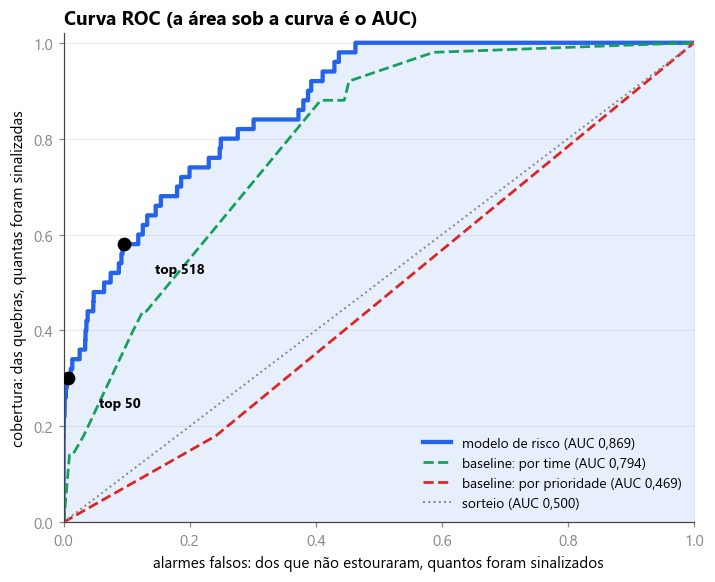

ROC AUC do modelo ............. 0,8693
ROC AUC do baseline por time .. 0,7945
ROC AUC de fila aleatória ..... 0,5063
ROC AUC por prioridade ........ 0,4693


In [16]:
fig, ax = plt.subplots(figsize=(6.6, 5.4))

rng = np.random.default_rng(SEMENTE)
curvas = [(risco_teste, 'modelo de risco', COR['accent'], 2.8, '-'),
          (score_time, 'baseline: por time', COR['verde'], 1.8, '--'),
          (score_prioridade, 'baseline: por prioridade', COR['danger'], 1.8, '--')]
for score, nome, cor, lw, ls in curvas:
    fpr, tpr, _ = roc_curve(y_teste, score)
    ax.plot(fpr, tpr, color=cor, lw=lw, ls=ls,
            label=f'{nome} (AUC {fmt(roc_auc_score(y_teste, score), 3)})')
ax.plot([0, 1], [0, 1], color=COR['cinza'], lw=1.3, ls=':', label='sorteio (AUC 0,500)')
fpr_m, tpr_m, _ = roc_curve(y_teste, risco_teste)
ax.fill_between(fpr_m, tpr_m, alpha=0.10, color=COR['accent'])

for k, rot in [(50, 'top 50'), (518, 'top 518')]:
    d = decisao_topo(k).astype(bool)
    ax.plot((~y_teste.astype(bool) & d).sum() / (N_TESTE - Q_TESTE), y_teste[d].sum() / Q_TESTE,
            'o', ms=8, color=COR['preto'], zorder=6)
    ax.annotate(rot, xy=((~y_teste.astype(bool) & d).sum() / (N_TESTE - Q_TESTE),
                         y_teste[d].sum() / Q_TESTE),
                xytext=(0.05 + (~y_teste.astype(bool) & d).sum() / (N_TESTE - Q_TESTE),
                        y_teste[d].sum() / Q_TESTE - 0.06), fontsize=9, fontweight='bold')

ax.set_xlabel('alarmes falsos: dos que não estouraram, quantos foram sinalizados')
ax.set_ylabel('cobertura: das quebras, quantas foram sinalizadas')
ax.set_title('Curva ROC (a área sob a curva é o AUC)', loc='left')
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout(); salvar_fig(fig, '03_curva_roc'); plt.show()

print(f'ROC AUC do modelo ............. {fmt(roc_auc_score(y_teste, risco_teste), 4)}')
print(f'ROC AUC do baseline por time .. {fmt(roc_auc_score(y_teste, score_time), 4)}')
print(f'ROC AUC de fila aleatória ..... {fmt(roc_auc_score(y_teste, rng.random(N_TESTE)), 4)}')
print(f'ROC AUC por prioridade ........ {fmt(roc_auc_score(y_teste, score_prioridade), 4)}')

**Achado:** o modelo alcança AUC de 0,8693, contra 0,7945 da melhor regra simples. A ordenação
por prioridade fica em 0,4693, abaixo do sorteio, e sua curva aparece embaixo da diagonal. A causa é
investigada na seção 4.10.3.

#### 4.6.4 Curva precisão-cobertura e PR-AUC

O ROC tem uma limitação quando o evento é raro. Seu eixo horizontal divide os alarmes falsos pelos
5.133 incidentes que não estouraram, de modo que uma centena de alarmes falsos desloca o ponto em
menos de dois centésimos. A classe majoritária dilui o erro.

A curva de precisão-cobertura retira essa classe do cálculo: nenhum dos dois eixos tem a classe
majoritária no denominador. A métrica resultante é mais severa e mais informativa para o topo da
fila, que é a parte utilizada pelo produto.

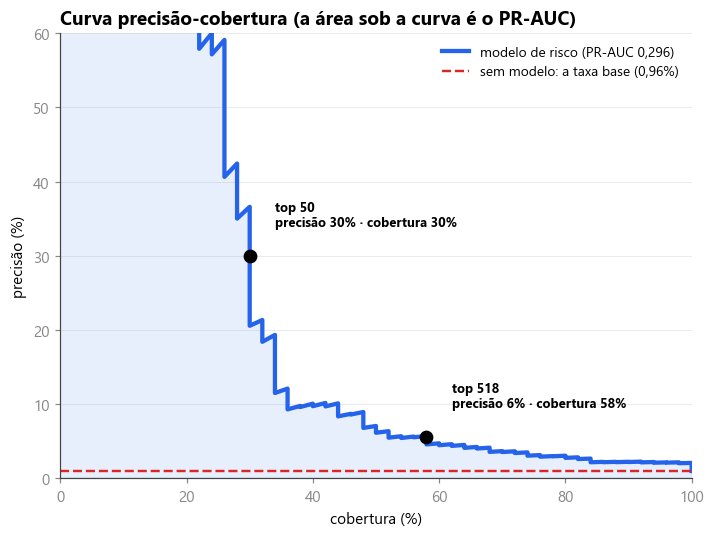

PR-AUC do modelo ................ 0,2958
PR-AUC de referência (taxa base)  0,0096
razão ........................... 31 vezes


In [17]:
prec_c, rec_c, _ = precision_recall_curve(y_teste, risco_teste)
PR_AUC = average_precision_score(y_teste, risco_teste)
BASE_TESTE = Q_TESTE / N_TESTE

fig, ax = plt.subplots(figsize=(6.6, 5.0))
ax.plot(rec_c * 100, prec_c * 100, color=COR['accent'], lw=2.8,
        label=f'modelo de risco (PR-AUC {fmt(PR_AUC, 3)})')
ax.fill_between(rec_c * 100, prec_c * 100, alpha=0.10, color=COR['accent'])
ax.axhline(BASE_TESTE * 100, color=COR['danger'], lw=1.6, ls='--',
           label=f'sem modelo: a taxa base ({fmt(BASE_TESTE*100)}%)')
for k, rot in [(50, 'top 50'), (518, 'top 518')]:
    a = achou(FILAS['modelo de risco'], k)
    ax.plot(a / Q_TESTE * 100, a / k * 100, 'o', ms=8, color=COR['preto'], zorder=6)
    ax.annotate(f'{rot}\nprecisão {a/k*100:.0f}% · cobertura {a/Q_TESTE*100:.0f}%',
                xy=(a / Q_TESTE * 100, a / k * 100),
                xytext=(a / Q_TESTE * 100 + 4, a / k * 100 + 4), fontsize=8.5, fontweight='bold')
ax.set_xlabel('cobertura (%)'); ax.set_ylabel('precisão (%)')
ax.set_title('Curva precisão-cobertura (a área sob a curva é o PR-AUC)', loc='left')
ax.set_xlim(0, 100); ax.set_ylim(0, 60)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); salvar_fig(fig, '04_curva_pr'); plt.show()

print(f'PR-AUC do modelo ................ {fmt(PR_AUC, 4)}')
print(f'PR-AUC de referência (taxa base)  {fmt(BASE_TESTE, 4)}')
print(f'razão ........................... {int(round(PR_AUC / BASE_TESTE))} vezes')

**Achado:** PR-AUC de 0,2958 contra referência de 0,0096, trinta e uma vezes a taxa da base.
Esta é a métrica reportada como principal indicador convencional, porque o ROC responde se o modelo
ordena bem o conjunto inteiro, enquanto o produto utiliza apenas o topo da fila.

### 4.7 XGBoost como baseline de comparação

O gradient boosting é a alternativa usual para dado tabular e frequentemente supera a regressão
logística. A comparação usa o mesmo pré-processamento, o mesmo corte de datas e as mesmas
características, de modo que a única diferença seja o algoritmo.

Duas configurações são avaliadas: a padrão e uma com peso na classe rara (`scale_pos_weight`),
recomendação corrente para base desbalanceada.

In [18]:
neg, pos = int((y_treino == 0).sum()), int(y_treino.sum())
PARAM_XGB = dict(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                 colsample_bytree=0.8, reg_lambda=1.0, eval_metric='logloss',
                 random_state=SEMENTE, n_jobs=4)

candidatos = {
    'regressão logística': modelo,
    'XGBoost (padrão)': Pipeline([('pre', novo_preprocessador()),
                                  ('clf', XGBClassifier(**PARAM_XGB))]),
    'XGBoost (peso na classe rara)': Pipeline([('pre', novo_preprocessador()),
                                               ('clf', XGBClassifier(scale_pos_weight=neg / pos,
                                                                     **PARAM_XGB))]),
}

comparacao = []
for nome, mod in candidatos.items():
    if nome != 'regressão logística':      # já treinado na seção 4.3
        mod.fit(X_treino, y_treino)
    p = mod.predict_proba(X_teste)[:, 1]
    o = np.argsort(-p)
    comparacao.append({
        'modelo': nome,
        'ROC AUC': round(roc_auc_score(y_teste, p), 4),
        'PR-AUC': round(average_precision_score(y_teste, p), 4),
        'top 50': int(y_teste[o[:50]].sum()),
        'top 518': int(y_teste[o[:518]].sum()),
        'top 20% da fila': int(y_teste[o[:int(0.2 * N_TESTE)]].sum()),
        'quebras previstas': round(float(p.sum()), 1),
    })

cmp_modelos = pd.DataFrame(comparacao).set_index('modelo')
print(cmp_modelos.to_string())
print()
print(f'quebras observadas no teste: {Q_TESTE}')
print('concentração nas 20% primeiras posições: ' + ' | '.join(
    f'{i}: {v / Q_TESTE * 100:.0f}%' for i, v in zip(cmp_modelos.index, cmp_modelos['top 20% da fila'])))

                               ROC AUC  PR-AUC  top 50  top 518  top 20% da fila  quebras previstas
modelo                                                                                             
regressão logística             0.8693  0.2958      15       29               36               48.1
XGBoost (padrão)                0.8679  0.2526      14       29               36               54.3
XGBoost (peso na classe rara)   0.8492  0.2367      12       27               31             1007.1

quebras observadas no teste: 50
concentração nas 20% primeiras posições: regressão logística: 72% | XGBoost (padrão): 72% | XGBoost (peso na classe rara): 62%


**Achado:** a regressão logística não perde em nenhuma das leituras.

- **ROC AUC:** 0,8693 contra 0,8679. Empate, porque a diferença não se distingue de ruído com 50
  casos positivos no teste.
- **PR-AUC:** 0,2958 contra 0,2526, vantagem de 17% para a logística.
- **Topo da fila:** 15 quebras nas 50 primeiras posições contra 14.
- **Calibração:** a soma das probabilidades da logística é 48,1 contra 50 quebras observadas. A
  configuração com peso na classe rara soma 1.007, vinte vezes o observado.

A última linha merece registro porque `scale_pos_weight` é recomendação frequente para dado
desbalanceado. Neste problema ela piorou a ordenação e destruiu a escala das probabilidades. Como a
projeção de atingimento do KPI depende de somar probabilidades, essa configuração seria inutilizável
mesmo que a ordenação fosse melhor.

**Decisão registrada.** A regressão logística é o modelo entregue. Não se trata de trocar desempenho
por simplicidade: ela empata ou supera o XGBoost neste problema, preserva a calibração e dispensa
ferramenta externa de explicação (seção 4.9). O XGBoost permanece como baseline de comparação.

### 4.8 Calibração do risco informado

A ordenação da fila não depende da escala das probabilidades, mas a interface exibe o valor e a
projeção do KPI o soma. É necessário verificar se o número informado corresponde ao observado.

O procedimento agrupa os incidentes pelo risco atribuído e compara, em cada faixa, a média informada
com a proporção de quebras observada.

In [19]:
FAIXAS = [0, 0.005, 0.01, 0.02, 0.05, 0.10, 1.0]
ROTULOS = ['0 a 0,5%', '0,5 a 1%', '1 a 2%', '2 a 5%', '5 a 10%', 'acima de 10%']

cal = pd.DataFrame({'risco': risco_teste, 'quebrou': y_teste})
cal['faixa'] = pd.cut(cal['risco'], FAIXAS, labels=ROTULOS)
calib = cal.groupby('faixa', observed=True).agg(
    incidentes=('quebrou', 'size'), quebras=('quebrou', 'sum'),
    informado=('risco', 'mean'), observado=('quebrou', 'mean'))
calib[['informado', 'observado']] = (calib[['informado', 'observado']] * 100).round(1)
print(calib.to_string())
print()
for k in (10, 50, 100):
    sel = ORDEM[:k]
    print(f'top {k:3d}: informado em média {fmt(risco_teste[sel].mean()*100)}% | '
          f'observado {fmt(y_teste[sel].mean()*100)}%')
print()
print(f'soma das probabilidades no teste: {fmt(risco_teste.sum(), 1)} | quebras observadas: {Q_TESTE}')

              incidentes  quebras  informado  observado
faixa                                                  
0 a 0,5%            3087        4        0.2        0.1
0,5 a 1%             863        8        0.7        0.9
1 a 2%               649        9        1.4        1.4
2 a 5%               447       12        3.0        2.7
5 a 10%              106        4        6.8        3.8
acima de 10%          31       13       20.3       41.9

top  10: informado em média 37,91% | observado 90,00%
top  50: informado em média 15,99% | observado 30,00%
top 100: informado em média 11,46% | observado 17,00%

soma das probabilidades no teste: 48,1 | quebras observadas: 50


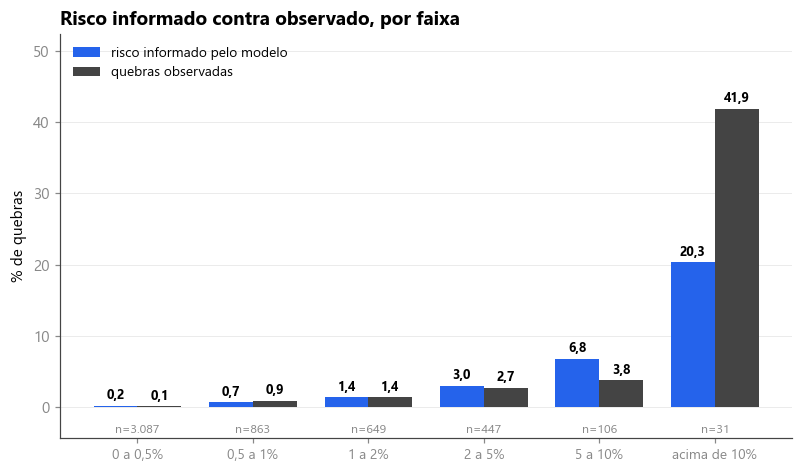

In [20]:
# figura 05: risco informado contra observado, por faixa
fig, ax = plt.subplots(figsize=(7.4, 4.4))
pos_x = np.arange(len(calib)); largura = 0.38
ax.bar(pos_x - largura / 2, calib['informado'], largura, color=COR['accent'],
       label='risco informado pelo modelo')
ax.bar(pos_x + largura / 2, calib['observado'], largura, color=COR['cinza_esc'],
       label='quebras observadas')
for i, (inf, obs, n) in enumerate(zip(calib['informado'], calib['observado'], calib['incidentes'])):
    ax.text(i - largura / 2, inf + 0.9, fmt(inf, 1), ha='center', fontsize=8.5, fontweight='bold')
    ax.text(i + largura / 2, obs + 0.9, fmt(obs, 1), ha='center', fontsize=8.5, fontweight='bold')
    ax.text(i, -3.6, f'n={fmt_int(n)}', ha='center', fontsize=8, color=COR['cinza'])
ax.set_xticks(pos_x); ax.set_xticklabels(calib.index, fontsize=9)
ax.set_ylabel('% de quebras')
ax.set_ylim(-4.4, max(calib['observado'].max(), calib['informado'].max()) * 1.25)
ax.set_title('Risco informado contra observado, por faixa', loc='left')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); salvar_fig(fig, '05_informado_vs_observado'); plt.show()

**Achado:** até a faixa de 5% o risco informado acompanha o observado. Acima disso o modelo
informa **menos** do que ocorre: na faixa mais alta a média informada fica em torno de 20% contra
cerca de 42% observados, e o mesmo sentido se repete nos três cortes do topo da fila.

O desvio é conservador, isto é, o valor exibido subestima o risco real. Duas ressalvas registradas
como limitação:

- a faixa mais alta reúne poucas dezenas de incidentes, o que torna a estimativa imprecisa, e a
  faixa de 5 a 10% desvia no sentido oposto, o que confirma que a medida é ruidosa nas pontas;
- nenhuma correção é aplicada sobre essas faixas. Ajustar um deslocamento medido em tão poucos casos
  produziria ajuste de ruído.

A soma das probabilidades no período é 48,1 contra 50 quebras observadas, erro de 3,8%. É essa
propriedade que sustenta a projeção de atingimento do KPI, desenvolvida no `06_projecao_kpi.ipynb`.
A seção 4.10.4 repete a medição em outros dois cortes de data e mostra que esse erro de 3,8% é o
melhor dos casos: a faixa observada vai de −27% a +7%. A leitura definitiva sobre a projeção está
lá.

### 4.9 Explicabilidade

O modelo entrega uma ordenação. Para que ela seja acionável, o analista precisa saber o que levou
cada incidente à posição em que está.

A regressão logística permite responder isso sem recurso externo, porque a pontuação que ela calcula
**é** uma soma de parcelas: um ponto de partida mais a contribuição de cada característica. Explicar
a previsão consiste em reapresentar essa soma.

**Sobre o SHAP.** Para modelos lineares o valor SHAP de uma característica tem forma fechada:
`peso × (valor observado − valor médio)`, exatamente o cálculo desta seção. A biblioteca resolveria o
mesmo problema por amostragem, com custo maior e resultado aproximado. Ela é dispensada por
redundância, não por limitação. A posição defendida é a de modelo interpretável por construção, em
vez de caixa preta acompanhada de explicação posterior.

#### 4.9.1 Decomposição da pontuação

A checagem seguinte é obrigatória: somar o ponto de partida às contribuições precisa reproduzir
exatamente a pontuação calculada pelo modelo. Sem ela, a explicação exibida poderia não corresponder
ao cálculo. Bastaria, por exemplo, um erro no mapeamento entre colunas codificadas e características
de origem para que a tabela saísse com números plausíveis e errados.

In [21]:
M_treino = modelo.named_steps['pre'].transform(X_treino)
M_teste = modelo.named_steps['pre'].transform(X_teste)
M_treino = M_treino.toarray() if hasattr(M_treino, 'toarray') else M_treino
M_teste = M_teste.toarray() if hasattr(M_teste, 'toarray') else M_teste

nomes_col = modelo.named_steps['pre'].get_feature_names_out()
pesos = modelo.named_steps['clf'].coef_[0]
media_treino = M_treino.mean(axis=0)

CONTRIB = (M_teste - media_treino) * pesos
PARTIDA = modelo.named_steps['clf'].intercept_[0] + float(media_treino @ pesos)

erro_max = np.abs((PARTIDA + CONTRIB.sum(axis=1)) - modelo.decision_function(X_teste)).max()
assert erro_max < 1e-8, f'a decomposição não reproduz a pontuação do modelo (erro {erro_max:.2e})'

print(f'erro máximo da reconstrução: {erro_max:.2e} (decomposição exata)')
print(f'ponto de partida, correspondente ao incidente médio: '
      f'{fmt(1 / (1 + np.exp(-PARTIDA)) * 100)}% de risco')

def caracteristica_de(nome_coluna):
    """Devolve a característica de origem de uma coluna codificada."""
    corpo = nome_coluna.split('__', 1)[1]
    return next(c for c in CARACTERISTICAS if corpo == c or corpo.startswith(c + '_'))

DONO = np.array([caracteristica_de(n) for n in nomes_col])
assert len(DONO) == len(nomes_col)
print(f'{len(nomes_col)} colunas codificadas atribuídas às '
      f'{len(set(DONO))} características de origem')

# a fila está reordenada; este mapa liga cada posição da fila à linha original do teste
assert df_teste['Número'].is_unique, 'Número repetido no teste'
_posicoes = pd.Series(np.arange(N_TESTE), index=df_teste['Número'].values)
FILA = FILAS['modelo de risco'].copy()
FILA['risco_%'] = FILA['score'] * 100
FILA['posição'] = FILA.index + 1
LINHA_ORIGINAL = _posicoes.loc[FILA['Número'].values].values

erro máximo da reconstrução: 2.66e-15 (decomposição exata)
ponto de partida, correspondente ao incidente médio: 0,41% de risco
136 colunas codificadas atribuídas às 10 características de origem


#### 4.9.2 Peso de cada característica

Duas leituras da mesma decomposição:

- **efeito**: quantas vezes a característica multiplica o risco em relação ao incidente médio;
- **peso**: a fatia daquela característica no total do que empurrou o risco para cima.

A segunda é a levada à interface, porque dispensa multiplicação em cadeia por parte do leitor.

In [22]:
ROTULO_DIA = ['segunda', 'terça', 'quarta', 'quinta', 'sexta', 'sábado', 'domingo']

def descreve(carac, valor):
    """Rótulo legível para o valor de uma característica."""
    if carac == 'dia_semana':
        return ROTULO_DIA[int(valor)]
    if carac == 'hora':
        return f'{int(valor)}h'
    if carac == 'is_feriado':
        return 'feriado' if int(valor) else 'dia comum'
    return str(valor)

def decompoe(posicao):
    """Contribuição de cada característica ao risco do incidente naquela posição da fila."""
    linha = CONTRIB[LINHA_ORIGINAL[posicao]]
    numero = FILA.loc[posicao, 'Número']
    dados = df_teste.loc[df_teste['Número'] == numero].iloc[0]
    t = pd.DataFrame([{'característica': c, 'valor': descreve(c, dados[c]),
                       'efeito': float(linha[DONO == c].sum())} for c in CARACTERISTICAS])
    t = t.sort_values('efeito', ascending=False).reset_index(drop=True)
    t['multiplica por'] = np.exp(t['efeito']).round(2)
    empurra = t.loc[t['efeito'] > 0, 'efeito'].sum()
    t['peso %'] = np.where(t['efeito'] > 0, t['efeito'] / empurra * 100, 0.0).round(1)
    t['efeito'] = t['efeito'].round(3)
    return t

TOPO = 0
alvo = FILA.loc[TOPO]
print(f"{alvo['Número']} · posição {alvo['posição']} de {fmt_int(N_TESTE)}")
print(f"risco estimado {fmt(alvo['risco_%'], 1)}% · "
      f"estourou de fato: {'sim' if alvo['violou'] else 'não'}")
print()
print(decompoe(TOPO).to_string(index=False))

INC8595245 · posição 1 de 5.183
risco estimado 56,1% · estourou de fato: sim

      característica     valor  efeito  multiplica por  peso %
           Categoria     cat31   2.192            8.95    37.6
             Produto      lsin   1.133            3.11    19.4
        Subcategoria    sub388   0.714            2.04    12.2
     Grupo designado    Team11   0.651            1.92    11.2
          dia_semana    sábado   0.453            1.57     7.8
          Aberto por    Manual   0.298            1.35     5.1
Item de configuração   IC00840   0.226            1.25     3.9
                hora       19h   0.161            1.17     2.8
          is_feriado dia comum   0.003            1.00     0.1
          Prioridade 3 - Média  -0.092            0.91     0.0


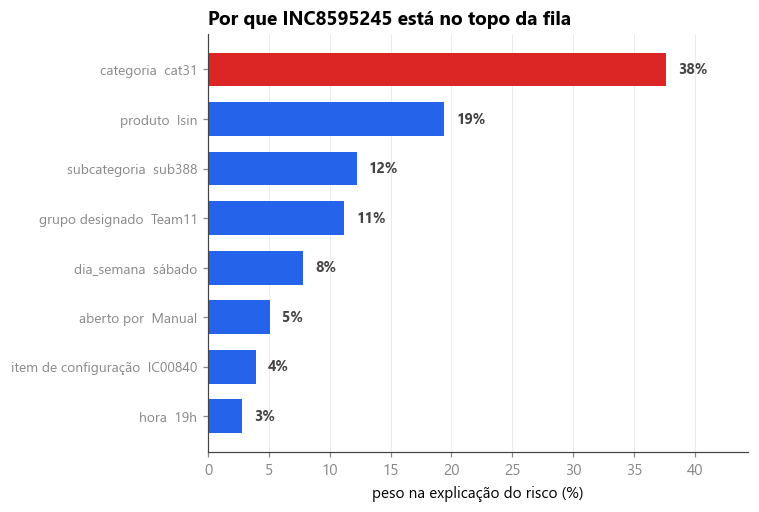

In [23]:
# figura 06: peso de cada característica na explicação do incidente no topo da fila
def grafico_peso(posicao, nome_arquivo=None):
    t = decompoe(posicao)
    t = t[t['peso %'] >= 1].sort_values('peso %')
    fig, ax = plt.subplots(figsize=(7.0, 0.42 * len(t) + 1.4))
    cores = [COR['danger'] if v >= 20 else COR['accent'] for v in t['peso %']]
    ax.barh(range(len(t)), t['peso %'], color=cores, height=0.68)
    for j, v in enumerate(t['peso %']):
        ax.text(v + 1, j, f'{v:.0f}%', va='center', fontsize=9.5, fontweight='bold',
                color=COR['cinza_esc'])
    ax.set_yticks(range(len(t)))
    ax.set_yticklabels([f'{c.lower()}  {v}' for c, v in zip(t['característica'], t['valor'])],
                       fontsize=9)
    ax.set_xlim(0, t['peso %'].max() * 1.18)
    ax.set_xlabel('peso na explicação do risco (%)')
    ax.set_title(f"Por que {FILA.loc[posicao, 'Número']} está no topo da fila", loc='left')
    ax.grid(axis='y', visible=False); ax.grid(axis='x', visible=True)
    plt.tight_layout()
    if nome_arquivo:
        salvar_fig(fig, nome_arquivo)
    plt.show()

grafico_peso(TOPO, '06_peso_explicacao')

#### 4.9.3 As características se sobrepõem?

Produto, categoria, subcategoria e item de configuração descrevem o mesmo incidente por ângulos
próximos. Quando duas características andam juntas, a regressão pode dividir o crédito entre elas de
mais de uma forma sem alterar o resultado final, o que torna a atribuição individual menos estável
que o total.

O teste retreina o modelo **sem** a categoria e observa para onde o peso migra.

In [24]:
SEM_CATEGORIA = [c for c in CATEGORICAS if c != 'Categoria']
COLS_SEM = SEM_CATEGORIA + NUMERICAS

pre_sem = ColumnTransformer([
    ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='(vazio)')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=100))]), SEM_CATEGORIA),
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), NUMERICAS),
])
modelo_sem = Pipeline([('pre', pre_sem),
                       ('clf', LogisticRegression(max_iter=5000, random_state=SEMENTE))])
Xtr_sem = df_treino[COLS_SEM].copy(); Xtr_sem[SEM_CATEGORIA] = Xtr_sem[SEM_CATEGORIA].astype(str)
Xte_sem = df_teste[COLS_SEM].copy(); Xte_sem[SEM_CATEGORIA] = Xte_sem[SEM_CATEGORIA].astype(str)
modelo_sem.fit(Xtr_sem, y_treino)

def efeitos(mod, Xtr_, Xte_, colunas, linha):
    A = mod.named_steps['pre'].transform(Xtr_); B = mod.named_steps['pre'].transform(Xte_)
    A = A.toarray() if hasattr(A, 'toarray') else A
    B = B.toarray() if hasattr(B, 'toarray') else B
    nm = mod.named_steps['pre'].get_feature_names_out(); w = mod.named_steps['clf'].coef_[0]
    contrib = (B[linha] - A.mean(axis=0)) * w
    dono = np.array([next(c for c in colunas if n.split('__', 1)[1] == c
                          or n.split('__', 1)[1].startswith(c + '_')) for n in nm])
    return {c: round(float(np.exp(contrib[dono == c].sum())), 2) for c in colunas}

linha_alvo = LINHA_ORIGINAL[TOPO]
risco_sem = modelo_sem.predict_proba(Xte_sem)[:, 1]
comp = pd.DataFrame({
    'com Categoria': pd.Series(efeitos(modelo, X_treino, X_teste, CARACTERISTICAS, linha_alvo)),
    'sem Categoria': pd.Series(efeitos(modelo_sem, Xtr_sem, Xte_sem, COLS_SEM, linha_alvo)),
}).astype(object)
comp['sem Categoria'] = comp['sem Categoria'].fillna('(removida)')
print(f"risco do {alvo['Número']} — com Categoria: {fmt(risco_teste[linha_alvo]*100, 1)}% | "
      f"sem Categoria: {fmt(risco_sem[linha_alvo]*100, 1)}%")
print()
print(comp.to_string())
print()
o_sem = np.argsort(-risco_sem)
print(f'quebras nas 50 primeiras posições — com Categoria: {achou(FILA, 50)} | '
      f'sem Categoria: {int(y_teste[o_sem[:50]].sum())}')
print(f'ROC AUC — com Categoria: {fmt(roc_auc_score(y_teste, risco_teste), 4)} | '
      f'sem: {fmt(roc_auc_score(y_teste, risco_sem), 4)}')

risco do INC8595245 — com Categoria: 56,1% | sem Categoria: 18,5%

                     com Categoria sem Categoria
Aberto por                    1.35          1.42
Categoria                     8.95    (removida)
Grupo designado               1.92          2.46
Item de configuração          1.25          1.36
Prioridade                    0.91          0.93
Produto                       3.11          3.81
Subcategoria                  2.04          1.86
dia_semana                    1.57          1.54
hora                          1.17          1.13
is_feriado                     1.0           1.0

quebras nas 50 primeiras posições — com Categoria: 15 | sem Categoria: 11
ROC AUC — com Categoria: 0,8693 | sem: 0,8516


**Achado:** duas conclusões em direções opostas.

1. **A atribuição individual é aproximada.** Ao remover a categoria, o efeito das demais
   características aumenta para cobrir a lacuna. A fatia de cada uma depende de quais outras estão no
   modelo, portanto os pesos devem ser lidos como ordem de importância e não como medida exata. O
   SHAP apresentaria a mesma instabilidade, porque ela vem da correlação entre as características e
   não do método de explicação.
2. **A sobreposição não é redundância.** A retirada da categoria reduz o desempenho da fila, o que
   indica que ela carrega informação não reproduzida pelas outras.

O total previsto continua confiável, porque foi validado fora do período de treino. A ressalva se
aplica à divisão entre características, e é por isso que a interface exibe ordem e faixa em vez de
valores com precisão decimal.

#### 4.9.4 Evidência histórica

A decomposição explica o cálculo do modelo. Uma segunda camada, independente dele, responde o que de
fato ocorreu com incidentes semelhantes.

O agrupamento é escolhido pelo primeiro critério com histórico suficiente no período de treino,
partindo do mais específico. O mínimo de trinta ocorrências evita que a taxa observada seja lida a
partir de um punhado de casos.

In [25]:
GRUPOS_EVIDENCIA = [('Item de configuração',), ('Grupo designado', 'Produto'), ('Grupo designado',)]
MINIMO_HISTORICO = 30

def evidencia(posicao):
    """Histórico observado no treino para o agrupamento mais específico com volume suficiente."""
    numero = FILA.loc[posicao, 'Número']
    dados = df_teste.loc[df_teste['Número'] == numero].iloc[0]
    for chaves in GRUPOS_EVIDENCIA:
        m = np.ones(len(df_treino), dtype=bool)
        for k in chaves:
            m &= (df_treino[k].astype(str).values == str(dados[k]))
        n = int(m.sum())
        if n >= MINIMO_HISTORICO:
            q = int(df_treino['violou'].values[m].sum())
            return {'chaves': chaves, 'n': n, 'quebras': q, 'taxa': q / n * 100}
    return None

print(f'taxa média no período de treino: {fmt(TAXA_TREINO * 100)}%')
print()
for p in range(8):
    e = evidencia(p)
    r = FILA.loc[p]
    d = ' + '.join(e['chaves']) if e else 'sem histórico suficiente'
    detalhe = f"{e['quebras']} de {e['n']} ({fmt(e['taxa'], 1)}%)" if e else '—'
    print(f"{r['posição']:2d}º {r['Número']}  risco {fmt(r['risco_%'], 1):>4s}%  | por {d}: {detalhe}")

taxa média no período de treino: 0,97%

 1º INC8595245  risco 56,1%  | por Item de configuração: 21 de 66 (31,8%)
 2º INC8607669  risco 50,4%  | por Item de configuração: 21 de 66 (31,8%)
 3º INC8579361  risco 47,2%  | por Item de configuração: 21 de 66 (31,8%)
 4º INC8599520  risco 42,9%  | por Item de configuração: 21 de 66 (31,8%)
 5º INC8601345  risco 40,4%  | por Item de configuração: 21 de 66 (31,8%)
 6º INC8590715  risco 39,8%  | por Item de configuração: 21 de 66 (31,8%)
 7º INC8614082  risco 33,1%  | por Grupo designado + Produto: 30 de 478 (6,3%)
 8º INC8614061  risco 29,1%  | por Item de configuração: 21 de 66 (31,8%)


#### 4.9.5 Saída para a interface

As três camadas reunidas em um bloco. É a informação exibida na tela de detalhe do incidente e a
mesma que alimenta a redação automática do alerta e do resumo diário.

O risco é apresentado como faixa acompanhada da referência da base, e não como valor isolado: uma
probabilidade de 5% não é interpretável sem saber que a média é de 0,97%.

In [26]:
def faixa_de(v):
    return 'ALTO' if v >= 10 else ('MÉDIO' if v >= 2 else 'BAIXO')

def explica(posicao, quantas=3):
    r = FILA.loc[posicao]
    numero = r['Número']
    dados = df_teste.loc[df_teste['Número'] == numero].iloc[0]
    linhas = [f"{numero} · risco {faixa_de(r['risco_%'])}",
              f"{fmt(r['risco_%'], 1)}% de chance de estourar "
              f"(a média da base é {fmt(TAXA_TREINO * 100)}%)",
              f"{r['posição']}º de {fmt_int(N_TESTE)} incidentes do período"]

    e = evidencia(posicao)
    if e:
        d = ' e '.join(f'{k.lower()} {dados[k]}' for k in e['chaves'])
        if e['quebras']:
            linhas.append(f"Histórico: dos {e['n']} incidentes com {d}, {e['quebras']} "
                          f"estouraram ({fmt(e['taxa'], 1)}%).")
        else:
            linhas.append(f"Histórico: dos {e['n']} incidentes com {d}, nenhum estourou.")

    t = decompoe(posicao)
    principais = t[t['peso %'] >= 5].head(quantas)
    if len(principais):
        itens = '; '.join(f"{row['característica'].lower()} {row['valor']} "
                          f"({row['peso %']:.0f}%)" for _, row in principais.iterrows())
        linhas.append(f'Principais motivos: {itens}.')
    return '\n'.join(linhas)

for p in (0, 1, 5):
    print(explica(p))
    print('-' * 78)

INC8595245 · risco ALTO
56,1% de chance de estourar (a média da base é 0,97%)
1º de 5.183 incidentes do período
Histórico: dos 66 incidentes com item de configuração IC00840, 21 estouraram (31,8%).
Principais motivos: categoria cat31 (38%); produto lsin (19%); subcategoria sub388 (12%).
------------------------------------------------------------------------------
INC8607669 · risco ALTO
50,4% de chance de estourar (a média da base é 0,97%)
2º de 5.183 incidentes do período
Histórico: dos 66 incidentes com item de configuração IC00840, 21 estouraram (31,8%).
Principais motivos: categoria cat31 (39%); produto lsin (20%); subcategoria sub56 (13%).
------------------------------------------------------------------------------
INC8590715 · risco ALTO
39,8% de chance de estourar (a média da base é 0,97%)
6º de 5.183 incidentes do período
Histórico: dos 66 incidentes com item de configuração IC00840, 21 estouraram (31,8%).
Principais motivos: categoria cat31 (40%); produto lsin (21%); subcat

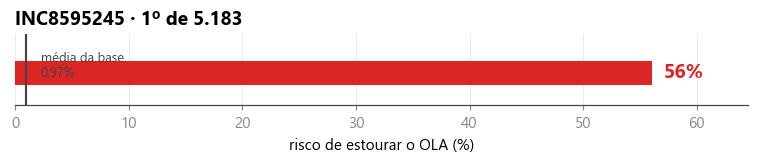

In [27]:
# figura 07: régua de risco com a média da base marcada
def regua_risco(posicao, nome_arquivo=None):
    r = FILA.loc[posicao]
    v = r['risco_%']
    fig, ax = plt.subplots(figsize=(7.0, 1.6))
    limite = max(v * 1.15, 12)
    ax.barh([0], [v], height=0.34,
            color=COR['danger'] if v >= 10 else (COR['ambar'] if v >= 2 else COR['accent']))
    ax.axvline(TAXA_TREINO * 100, color=COR['cinza_esc'], lw=1.4)
    ax.annotate(f'média da base\n{fmt(TAXA_TREINO*100)}%', xy=(TAXA_TREINO * 100, 0.30),
                xytext=(TAXA_TREINO * 100 + limite * 0.02, 0.30), fontsize=8.5,
                color=COR['cinza_esc'], va='top')
    ax.annotate(f'{v:.0f}%', xy=(v, 0), xytext=(v + limite * 0.015, 0), fontsize=13,
                fontweight='bold', color=COR['danger'], va='center')
    ax.set_xlim(0, limite); ax.set_ylim(-0.45, 0.55); ax.set_yticks([])
    ax.set_xlabel('risco de estourar o OLA (%)')
    ax.set_title(f"{r['Número']} · {r['posição']}º de {fmt_int(N_TESTE)}", loc='left')
    ax.spines['left'].set_visible(False)
    ax.grid(axis='y', visible=False); ax.grid(axis='x', visible=True)
    plt.tight_layout()
    if nome_arquivo:
        salvar_fig(fig, nome_arquivo)
    plt.show()

regua_risco(TOPO, '07_regua_risco')

In [28]:
# cobertura: a explicação existe para toda a fila, não apenas para os exemplos escolhidos
AMOSTRA = min(300, N_TESTE)
com_historico = sum(1 for p in range(AMOSTRA) if evidencia(p))
concentracao_top3 = [decompoe(p)['peso %'].head(3).sum() for p in range(AMOSTRA)]

print(f'nos {AMOSTRA} primeiros da fila:')
print(f'  com histórico suficiente (mínimo de {MINIMO_HISTORICO} casos): '
      f'{com_historico} ({com_historico / AMOSTRA * 100:.0f}%)')
print(f'  explicados apenas pela decomposição: {AMOSTRA - com_historico} '
      f'({(AMOSTRA - com_historico) / AMOSTRA * 100:.0f}%)')
print(f'  peso concentrado nas 3 principais características: '
      f'{np.mean(concentracao_top3):.0f}% em média')

nos 300 primeiros da fila:
  com histórico suficiente (mínimo de 30 casos): 300 (100%)
  explicados apenas pela decomposição: 0 (0%)
  peso concentrado nas 3 principais características: 79% em média


**Achado:** todos os 300 primeiros incidentes da fila têm histórico suficiente para exibir a
evidência observada, e a decomposição está sempre disponível, de modo que nenhum incidente fica sem
explicação. O peso se concentra em cerca de 79% nas três principais características, o que permite
uma explicação de três linhas em vez de uma lista com dez itens.

### 4.10 Verificações de robustez

#### 4.10.1 O modelo generaliza além dos perfis vistos no treino?

Uma objeção possível: o modelo poderia estar apenas memorizando combinações de características vistas
no treino e reproduzindo a taxa histórica de cada uma. Nesse caso não haveria generalização, e o
desempenho colapsaria diante de combinações novas.

A verificação mede quantos incidentes do teste apresentam combinação de características inédita, e
compara o desempenho do modelo nesse subconjunto.

In [29]:
CHAVE_PERFIL = ['Grupo designado', 'Produto', 'Categoria', 'Subcategoria', 'Item de configuração']

perfil = lambda d: d[CHAVE_PERFIL].astype(str).agg('|'.join, axis=1)
perfis_treino = set(perfil(df_treino))
inedito = ~perfil(df_teste).isin(perfis_treino).values

print(f'perfis distintos no treino: {fmt_int(len(perfis_treino))}')
print(f'incidentes de teste com perfil inédito: {fmt_int(inedito.sum())} '
      f'({inedito.mean()*100:.0f}% do teste)')
print(f'  quebras entre os inéditos ....... {int(y_teste[inedito].sum())}')
print(f'  quebras entre os já vistos ...... {int(y_teste[~inedito].sum())}')
print()
for rotulo, m in [('perfis inéditos', inedito), ('perfis já vistos', ~inedito)]:
    if y_teste[m].sum() >= 5:
        print(f'{rotulo}: ROC AUC {fmt(roc_auc_score(y_teste[m], risco_teste[m]), 4)} '
              f'({int(y_teste[m].sum())} quebras em {fmt_int(m.sum())} incidentes)')

perfis distintos no treino: 7.826
incidentes de teste com perfil inédito: 2.625 (51% do teste)
  quebras entre os inéditos ....... 27
  quebras entre os já vistos ...... 23

perfis inéditos: ROC AUC 0,8151 (27 quebras em 2.625 incidentes)
perfis já vistos: ROC AUC 0,9225 (23 quebras em 2.558 incidentes)


**Achado:** 2.625 incidentes de teste, ou 51% do total, apresentam combinação de características
inédita, e é entre eles que estão 27 das 50 quebras. Nesse subconjunto o modelo mantém ROC AUC de
0,8151.

O resultado descarta a hipótese de memorização: o modelo compõe o risco a partir das características
individuais, o que permite pontuar um incidente cuja combinação exata nunca ocorreu. Registra-se
também a diferença de desempenho entre os dois subconjuntos: 0,8151 nos perfis inéditos contra 0,9225
nos já vistos. O modelo é melhor onde tem histórico, o que é esperado, mas continua útil onde não
tem.

#### 4.10.2 Características de estado acrescentam sinal?

As características usadas até aqui são estáticas: prioridade, produto, time e categoria não mudam ao
longo do tempo. Uma segunda família descreve o **estado do ambiente no instante da abertura**, como o
histórico recente do ativo ou a carga do time naquele momento.

Cada valor é calculado usando apenas o que já havia ocorrido até o instante de abertura daquele
incidente, o que reproduz a informação disponível em produção.

| Característica | Descrição |
|---|---|
| `ativo_inc_30d` | incidentes do mesmo item de configuração nos 30 dias anteriores |
| `ativo_quebras_90d` | quebras do mesmo item de configuração nos 90 dias anteriores |
| `time_abertos_agora` | incidentes do mesmo time ainda em aberto naquele instante |
| `inc_no_dia` | incidentes abertos no mesmo dia, antes deste |

In [30]:
df_est = df_kpi.sort_values('Aberto').reset_index(drop=True).copy()
df_est['fim'] = df_est['Resolvido'].fillna(df_est['Encerrado'])
t_abre = df_est['Aberto'].values.astype('datetime64[ns]')
t_fim = df_est['fim'].values.astype('datetime64[ns]')
alvo_est = df_est['violou'].values

def contagem_janela(chave, dias, apenas_quebras=False):
    """Para cada incidente, conta ocorrências anteriores da mesma chave dentro da janela."""
    janela = np.timedelta64(dias, 'D')
    saida = np.zeros(len(df_est), dtype=int)
    for _, idx in df_est.groupby(chave).indices.items():
        idx = np.asarray(idx)
        tempos = t_abre[idx]
        inicio = np.searchsorted(tempos, tempos - janela, side='left')
        anteriores = np.arange(len(idx))          # a base está ordenada por abertura
        if apenas_quebras:
            acum = np.concatenate([[0], np.cumsum(alvo_est[idx])])
            saida[idx] = acum[anteriores] - acum[inicio]
        else:
            saida[idx] = anteriores - inicio
    return saida

df_est['ativo_inc_30d'] = contagem_janela('Item de configuração', 30)
df_est['ativo_quebras_90d'] = contagem_janela('Item de configuração', 90, apenas_quebras=True)

# incidentes do mesmo time em aberto no instante: abertos antes menos encerrados antes
abertos = np.zeros(len(df_est), dtype=int)
for _, idx in df_est.groupby('Grupo designado').indices.items():
    idx = np.asarray(idx)
    inicios = np.sort(t_abre[idx])
    fins = np.sort(t_fim[idx][~pd.isna(t_fim[idx])])
    abertos[idx] = (np.searchsorted(inicios, t_abre[idx], side='left')
                    - np.searchsorted(fins, t_abre[idx], side='right'))
df_est['time_abertos_agora'] = np.clip(abertos, 0, None)
df_est['inc_no_dia'] = df_est.groupby('dia').cumcount()

ESTADO = ['ativo_inc_30d', 'ativo_quebras_90d', 'time_abertos_agora', 'inc_no_dia']
separacao = df_est.groupby('violou')[ESTADO].mean().T
separacao.columns = ['não estourou', 'estourou']
separacao['razão'] = (separacao['estourou'] / separacao['não estourou']).round(2)
print(separacao.round(2).to_string())

                    não estourou  estourou  razão
ativo_inc_30d              48.78     34.90   0.72
ativo_quebras_90d           0.93      1.75   1.88
time_abertos_agora        105.11     48.29   0.46
inc_no_dia                 39.82     36.65   0.92


In [31]:
tr_est = df_est[df_est['dia'] < CORTE]
te_est = df_est[df_est['dia'] >= CORTE]

def treina_com(colunas_num, rotulo):
    pre = ColumnTransformer([
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='(vazio)')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=100))]), CATEGORICAS),
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc', StandardScaler())]), colunas_num),
    ])
    pipe = Pipeline([('pre', pre), ('clf', LogisticRegression(max_iter=5000, random_state=SEMENTE))])
    cols = CATEGORICAS + colunas_num
    A = tr_est[cols].copy(); A[CATEGORICAS] = A[CATEGORICAS].astype(str)
    B = te_est[cols].copy(); B[CATEGORICAS] = B[CATEGORICAS].astype(str)
    pipe.fit(A, tr_est['violou'])
    p = pipe.predict_proba(B)[:, 1]
    o = np.argsort(-p)
    yv = te_est['violou'].values
    return {'conjunto': rotulo, 'características': len(cols),
            'ROC AUC': round(roc_auc_score(yv, p), 4),
            'PR-AUC': round(average_precision_score(yv, p), 4),
            'top 50': int(yv[o[:50]].sum()), 'top 518': int(yv[o[:518]].sum())}

cmp_estado = pd.DataFrame([treina_com(NUMERICAS, 'sem características de estado'),
                           treina_com(NUMERICAS + ESTADO, 'com características de estado')])
print(cmp_estado.set_index('conjunto').to_string())

                               características  ROC AUC  PR-AUC  top 50  top 518
conjunto                                                                        
sem características de estado               10   0.8693  0.2958      15       29
com características de estado               14   0.8793  0.2982      15       30


**Achado:** o ganho no modelo é marginal. O ROC AUC sobe de 0,8693 para 0,8793 e o PR-AUC de
0,2958 para 0,2982, com uma quebra adicional no corte de 518 e nenhuma no topo da fila. Com 50 casos
positivos no teste, essa diferença não se distingue de ruído.

As características ficam **fora do conjunto entregue**: exigiriam manter estado histórico calculado a
cada abertura na aplicação, contra ganho não demonstrável. A decisão é registrada como resultado
negativo, não como omissão.

**Registro adicional, sobre a direção dos números.** A comparação de médias contraria a intuição em
duas das quatro características:

- `ativo_quebras_90d` é 1,88 vez maior nos incidentes que estouraram, o que confirma o efeito do ativo
  crônico já identificado na análise exploratória;
- `time_abertos_agora` é **menor** nas quebras: 48 contra 105 incidentes em aberto. As quebras ocorrem
  quando a equipe está menos carregada, não mais.

A segunda linha é a terceira medição independente que contraria a hipótese de acúmulo levantada na
mentoria com a Locaweb. As duas anteriores estão no `03_previsao_volume.ipynb`: a correlação entre
backlog diário e quebras é de −0,139 em dias úteis, e o volume diário explica apenas 2,5% da variação
no número de quebras. Nenhuma delas sustenta que o acúmulo de trabalho provoque estouro de OLA.

#### 4.10.3 Por que a ordenação por prioridade não funciona

A ordenação por prioridade obteve AUC de 0,4693 na seção 4.6.3, abaixo do sorteio. Mecanicamente isso
implica que, no agregado, os incidentes de prioridade alta estouram menos que os de prioridade média.
A verificação abaixo confronta taxa de quebra e tempo de resolução das duas prioridades.

**Atenção à leitura.** O agregado não autoriza conclusão causal. A explicação intuitiva, de que a
priorização evita o estouro, foi testada em 04/08/2026 controlando por uma terceira variável e **não
se sustentou**: a diferença entre P2 e P3 é efeito de composição. O desenvolvimento está no
`05_causas_recorrentes.ipynb`, seção 4.6, e a síntese aparece na leitura desta seção.

In [32]:
por_prioridade = df_kpi.groupby(df_kpi['Prioridade'].astype(str)).agg(
    incidentes=('violou', 'size'), quebras=('violou', 'sum'))
por_prioridade['taxa de quebra %'] = (por_prioridade['quebras']
                                      / por_prioridade['incidentes'] * 100).round(2)
por_prioridade['duração mediana'] = df_kpi.groupby(
    df_kpi['Prioridade'].astype(str))['Duração'].median()
print(por_prioridade.to_string())

            incidentes  quebras  taxa de quebra %  duração mediana
Prioridade                                                        
2 - Alta          5159       42              0.81           1577.0
3 - Média        20441      206              1.01           6328.0


**Achado, com a ressalva que o controle impôs.**

No agregado o P2 apresenta taxa de quebra de 0,81% contra 1,01% do P3, e duração mediana próxima de um
quarto da do P3. A leitura imediata seria que a priorização evita o estouro. Ela não resiste ao
controle.

Ao estratificar por frequência do problema (`05_causas_recorrentes.ipynb`, seção 4.6), a diferença
entre as prioridades desaparece e nas faixas de caso inédito ela inverte: o P2 chega a 2,27% contra
1,54% do P3. A média favorável ao P2 vinha da composição, porque apenas 7,9% dos casos inéditos são P2
contra 30,8% dos problemas que repetem vinte vezes ou mais. É um caso de paradoxo de Simpson.

O que permanece verificado:

- **a duração menor do P2 é real** e vale dentro de todas as faixas de frequência;
- **o AUC de 0,4693 é fato medido**, e continua significando que a ordenação padrão de ITSM não separa
  quem vai estourar;
- **a explicação desse AUC não é a priorização**, e sim a frequência do problema, que é a variável com
  a qual a prioridade está correlacionada.

A inversão observada nas faixas inéditas se apoia em 17 e 9 quebras, volume que não permite afirmá-la
como fato. O que está estabelecido é que o agregado é efeito de composição e não evidência de que a
priorização previna estouro.

#### 4.10.4 Estabilidade do resultado

Duas verificações finais. A primeira repete o corte temporal em outra data, para confirmar que o
resultado não depende da escolha de 01/10/2025. A segunda compara o corte temporal com uma separação
aleatória, para quantificar o otimismo que a separação aleatória introduz.

In [33]:
def avalia_corte_data(data_corte):
    tr = df_kpi[df_kpi['dia'] < data_corte]
    te = df_kpi[df_kpi['dia'] >= data_corte]
    if te['violou'].sum() < 20:
        return None
    pipe = Pipeline([('pre', novo_preprocessador()),
                     ('clf', LogisticRegression(max_iter=5000, random_state=SEMENTE))])
    pipe.fit(matriz_x(tr), tr['violou'])
    p = pipe.predict_proba(matriz_x(te))[:, 1]
    yv = te['violou'].values
    o = np.argsort(-p)
    return {'corte': f'{data_corte:%d/%m/%Y}', 'teste': len(te), 'quebras': int(yv.sum()),
            'ROC AUC': round(roc_auc_score(yv, p), 4),
            'PR-AUC': round(average_precision_score(yv, p), 4),
            'top 50': int(yv[o[:50]].sum()),
            'quebras previstas': round(p.sum(), 1)}

estabilidade = [avalia_corte_data(pd.Timestamp(d))
                for d in ['2025-09-01', '2025-10-01', '2025-11-01']]
print(pd.DataFrame([e for e in estabilidade if e]).set_index('corte').to_string())

            teste  quebras  ROC AUC  PR-AUC  top 50  quebras previstas
corte                                                                 
01/09/2025   7507       61   0.8684  0.2702      16               65.3
01/10/2025   5183       50   0.8693  0.2958      15               48.1
01/11/2025   3057       39   0.8774  0.3177      13               28.6


In [34]:
# separação aleatória, para medir o otimismo que ela introduz
from sklearn.model_selection import train_test_split

tr_a, te_a = train_test_split(df_kpi, test_size=len(df_teste) / len(df_kpi),
                              random_state=SEMENTE, stratify=df_kpi['violou'])
pipe_a = Pipeline([('pre', novo_preprocessador()),
                   ('clf', LogisticRegression(max_iter=5000, random_state=SEMENTE))])
pipe_a.fit(matriz_x(tr_a), tr_a['violou'])
p_a = pipe_a.predict_proba(matriz_x(te_a))[:, 1]
y_a = te_a['violou'].values
o_a = np.argsort(-p_a)

print(f'{"separação":<24s} {"ROC AUC":>9s} {"PR-AUC":>9s} {"top 50":>8s}')
print(f'{"temporal (adotada)":<24s} {fmt(roc_auc_score(y_teste, risco_teste), 4):>9s} '
      f'{fmt(PR_AUC, 4):>9s} {achou(FILA, 50):>8d}')
print(f'{"aleatória":<24s} {fmt(roc_auc_score(y_a, p_a), 4):>9s} '
      f'{fmt(average_precision_score(y_a, p_a), 4):>9s} {int(y_a[o_a[:50]].sum()):>8d}')

separação                  ROC AUC    PR-AUC   top 50
temporal (adotada)          0,8693    0,2958       15
aleatória                   0,8260    0,1526       10


**Achado, em duas partes de sinais opostos.**

**A capacidade de ordenação é estável.** Nos três cortes o ROC AUC fica entre 0,8684 e 0,8774 e o
PR-AUC entre 0,2702 e 0,3177. O resultado não depende da escolha de 01/10/2025.

**A soma das probabilidades não é estável.** É o achado que corrige uma leitura otimista da
seção 4.8:

| Corte | Quebras previstas | Observadas | Erro |
|---|---|---|---|
| 01/09/2025 | 65,3 | 61 | +7,0% |
| 01/10/2025 | 48,1 | 50 | −3,8% |
| 01/11/2025 | 28,6 | 39 | **−26,7%** |

O erro de 3,8% do corte adotado é o melhor dos três casos, não o comportamento típico. A faixa
observada vai de −27% a +7%.

**Consequência para a projeção do KPI.** O mecanismo de somar probabilidades continua válido, porque
não existe viés sistemático em uma direção só, mas o resultado precisa ser apresentado como estimativa
com incerteza da ordem de um quarto do valor, e não como número fechado. O `06_projecao_kpi.ipynb`
deve exibir faixa, e a fonte provável do erro no corte de novembro merece investigação: é o único que
treina sobre outubro, mês afetado pela mudança de processo de setembro documentada no `01_eda.ipynb`.

**Sobre a separação aleatória.** Ela produz métricas *inferiores* às do corte temporal neste caso
(ROC AUC 0,8260 contra 0,8693; PR-AUC 0,1526 contra 0,2958), o que é o oposto do resultado usual. A
explicação está na composição: a separação aleatória distribui o treino ao longo dos três anos,
enquanto o corte temporal concentra o treino no período imediatamente anterior ao teste, que é mais
representativo dele. Isso reforça a escolha do corte temporal, que já era exigido pelo protocolo de
uso real.

## 5. Conclusões e próximos passos

### Principais achados

1. **O modelo ordena a fila com ganho relevante sobre a prática atual.** Nas 50 primeiras posições
   encontra 15 das 50 quebras do período, contra 6 da melhor regra simples (ordenação por taxa
   histórica do time) e 1 da ordenação por prioridade. O ganho sobre a melhor alternativa varia de
   29% a 150% e é maior no topo, que é a parte efetivamente utilizada.
2. **A regressão logística empata ou supera o XGBoost.** ROC AUC de 0,8693 contra 0,8679, e PR-AUC de
   0,2958 contra 0,2526. A escolha do modelo linear não troca desempenho por simplicidade.
3. **Balancear a classe rara é contraproducente aqui.** O XGBoost com `scale_pos_weight` piora a
   ordenação e prevê 1.007 quebras onde ocorreram 50, o que inviabilizaria a projeção do KPI.
4. **A acurácia não é aplicável.** Com prevalência de 0,97%, um classificador que nunca sinaliza nada
   atinge 99,04% de acurácia contra 90,16% do modelo no corte de 518. A avaliação usa matriz de
   confusão por corte, precisão, cobertura, PR-AUC e curva de ganho.
5. **A soma das probabilidades serve para projetar, com incerteza declarada.** No corte adotado são
   48,1 quebras previstas contra 50 observadas, erro de 3,8%. Repetida em outros dois cortes de data,
   a mesma medição erra de −27% a +7%. O mecanismo é válido, mas a projeção do KPI precisa sair como
   faixa e não como número fechado.
6. **O risco informado é calibrado até 5% e conservador acima disso.** Na faixa mais alta o modelo
   informa cerca de 20% contra 42% observados. O desvio é para o lado seguro, mas está medido em
   poucas dezenas de incidentes e nenhuma correção é aplicada.
7. **A explicabilidade dispensa SHAP.** A decomposição da pontuação reproduz a previsão do modelo com
   erro na ordem de 10⁻¹⁵, e o peso se concentra em cerca de 79% nas três principais características.
8. **A ordenação por prioridade tem AUC de 0,4693, abaixo do sorteio.** O fato está medido, mas a
   explicação intuitiva não se sustenta: ao controlar pela frequência do problema, a vantagem
   agregada do P2 desaparece. Ela vinha da composição, não da priorização. Ver
   `05_causas_recorrentes.ipynb`.
9. **O modelo generaliza.** Metade dos incidentes de teste tem combinação de características inédita,
   e neles a ordenação se mantém com ROC AUC de 0,8151, contra 0,9225 nos perfis já vistos.
10. **A hipótese de acúmulo volta a não se sustentar.** As quebras ocorrem quando a equipe tem menos
    incidentes em aberto, não mais: 48 contra 105 em média. É a terceira medição independente no mesmo
    sentido, somada às duas do `03_previsao_volume.ipynb`.

### Decisões que isso implica

- **Modelo entregue:** regressão logística com dez características disponíveis na abertura. O XGBoost
  permanece registrado como baseline de comparação.
- **Características de estado ficam fora:** ganho dentro da margem de ruído contra o custo de manter
  estado histórico na aplicação.
- **Interface exibe faixa, posição e evidência histórica**, com o valor percentual acompanhado da
  média da base. Não exibe multiplicadores por característica, porque a divisão entre características
  correlacionadas é aproximada.
- **O corte da fila é parâmetro de operação**, não do modelo. A entrega é a tabela de precisão e
  cobertura por corte, para que a decisão seja tomada com a capacidade real da equipe.

### Próximos passos

- [ ] `05_causas_recorrentes.ipynb`: agrupar causas recorrentes e formalizar a detecção de incidentes
      recorrentes.
- [ ] `06_projecao_kpi.ipynb`: combinar a previsão de volume com o risco por incidente para projetar o
      atingimento das metas anuais, apresentando o resultado como faixa (ver achado 5) e investigando
      a origem do desvio no corte de novembro.
- [ ] Serializar o modelo treinado para consumo pela aplicação Django.
- [ ] Definir a periodicidade de re-treino, considerando que o rótulo de elegibilidade depende do
      fechamento do incidente e a cauda recente da série fica incompleta.

### Pontos abertos

- O conjunto de teste tem 50 quebras. Diferenças pequenas entre configurações não são distinguíveis
  de ruído, e isso está declarado em cada comparação.
- A calibração nas faixas superiores está medida em poucas dezenas de casos. Uma correção só deve ser
  considerada com volume maior de observações.
- O desvio de −26,7% na soma das probabilidades no corte de 01/11/2025 não está explicado. A hipótese
  em aberto é a influência da mudança de processo de setembro de 2025 sobre o treino desse corte.
- O modelo é treinado com dados de 2025. A estabilidade em regime de mudança de processo, como a
  ocorrida em setembro de 2025 e documentada no `01_eda.ipynb`, não foi avaliada.